In [642]:
import kagglehub
import os


file_path = kagglehub.dataset_download("harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows")
print(file_path)
print(os.listdir(file_path))

Using Colab cache for faster access to the 'imdb-dataset-of-top-1000-movies-and-tv-shows' dataset.
/kaggle/input/imdb-dataset-of-top-1000-movies-and-tv-shows
['imdb_top_1000.csv']


1. DATASET 1: Top 1000 Movies by IMDB Rating











In [643]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "imdb_top_1000.csv"

# IMDB Dataset loaded
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows",
  file_path,
)

imdb_df = df[[
    "Poster_Link",
    "Series_Title",
    "Released_Year",
    "Certificate",
    "Genre",
    "Runtime",
    "IMDB_Rating",
    "Meta_score",
    "Director",
    "Star1",
    "Star2",
    "Star3",
    "Star4",
    "No_of_Votes",
    "Gross"
]]

imdb_df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-top-1000-movies-and-tv-shows' dataset.


,Poster_Link,Series_Title,Released_Year,Certificate,Genre,Runtime,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,Drama,142 min,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,"Crime, Drama",175 min,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,"Action, Crime, Drama",152 min,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,"Crime, Drama",202 min,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,"Crime, Drama",96 min,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


2. DATASET 1: Preprocessing

In [644]:
import pandas as pd

# Encoding
# Due to having multiple genres for a single movie, we split them apart

# Split genres
imdb_df["Genre"] = imdb_df["Genre"].str.split(",")
imdb_df = imdb_df.explode("Genre")
imdb_df["Genre"] = imdb_df["Genre"].str.strip()

# Encode genres
genre_dummies = pd.get_dummies(imdb_df["Genre"])

# Combine back WITHOUT aggregating everything blindly
imdb_df = pd.concat([imdb_df.drop("Genre", axis=1), genre_dummies], axis=1)

# Now group safely
imdb_df = imdb_df.groupby(level=0).max()


#Replace runtime string with numeric values
imdb_df["Runtime"] = imdb_df["Runtime"].str.replace(" min", "")
imdb_df["Runtime"] = pd.to_numeric(imdb_df["Runtime"], errors="coerce")

# Data cleaning
# Cleans up Gross income of movies, removing commas and replacing the strings with numeric datatypes
imdb_df.info()

# Shows us there are many missing components in both Meta_score and Gross sections of the dataset
#  4   Meta_score     843 non-null    float64
#  5   Gross          831 non-null    float64

# Exactly 157 missing in Meta_score and 169 missing in Gross
# imdb_df = imdb_df.dropna()
# There would then be 750 rows of completed rows, however we lose 25% of the data


# Alternative Method: Median imputation
# Convert 'Gross' column to numeric, handling commas and then filling NaNs
# Ensure the column is string type before applying string methods
imdb_df.loc[:, 'Gross'] = imdb_df['Gross'].astype(str).str.replace(',', '', regex=False)
imdb_df.loc[:, 'Gross'] = pd.to_numeric(imdb_df['Gross'], errors='coerce')

# Impute the new median in missing data positons
imdb_df.loc[:, "Gross"] = imdb_df["Gross"].fillna(imdb_df["Gross"].median())

imdb_df.loc[:, "Meta_score"] = imdb_df["Meta_score"].fillna(imdb_df["Meta_score"].median())
imdb_df.info()
imdb_df.head()

/tmp/ipykernel_7886/79829957.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_df["Genre"] = imdb_df["Genre"].str.split(",")


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   int64  
 5   IMDB_Rating    1000 non-null   float64
 6   Meta_score     843 non-null    float64
 7   Director       1000 non-null   object 
 8   Star1          1000 non-null   object 
 9   Star2          1000 non-null   object 
 10  Star3          1000 non-null   object 
 11  Star4          1000 non-null   object 
 12  No_of_Votes    1000 non-null   int64  
 13  Gross          831 non-null    object 
 14  Action         1000 non-null   bool   
 15  Adventure      1000 non-null   bool   
 16  Animation      1000 non-null   bool   
 17  Biography      1000 non-null   bool   
 18  Comedy        

/tmp/ipykernel_7886/79829957.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  imdb_df.loc[:, "Gross"] = imdb_df["Gross"].fillna(imdb_df["Gross"].median())


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,Director,Star1,Star2,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,...,False,False,False,False,False,False,False,False,False,False
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,...,False,False,False,False,False,False,False,False,False,False
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,...,False,False,False,False,False,False,False,False,False,False
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,...,False,False,False,False,False,False,False,False,False,False
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,...,False,False,False,False,False,False,False,False,False,False


Why IMDB dataset? I've always enjoyed movies and being able to see the distinct details of a movie and find relations between them seemed pretty interesting to me. I wanted to see the correlation between the different features and find if there was a real correlation between them and the IMDb rating

**Cite a source for IMDB DATASET!**

**Dataset 1: IMDb ratings (Linear Regression)**



In [645]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = imdb_df[["Released_Year", "Meta_score", "No_of_Votes", "Gross", "Runtime"]].copy()
y = imdb_df["IMDB_Rating"]

X["Released_Year"] = pd.to_numeric(X["Released_Year"], errors="coerce")

model_df = pd.concat([X, y], axis=1).dropna()
X = model_df[["Released_Year", "Meta_score", "No_of_Votes", "Gross", "Runtime"]]
y = model_df["IMDB_Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#Displays the average squared error and the Sq
print("MSE:", np.sqrt(mse))
print("R2:", r2)



MSE: 0.20722191776360124
R2: 0.34416306679458264


**DISPLAYING THE MODEL PREDICTIONS FOR IMDb RATINGS (LINEAR REGRESSION)**

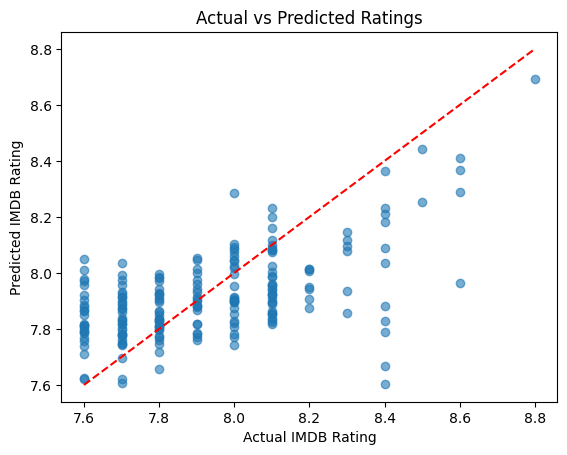

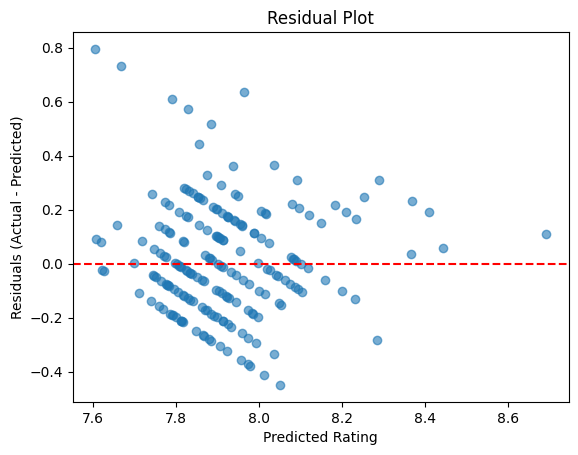

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

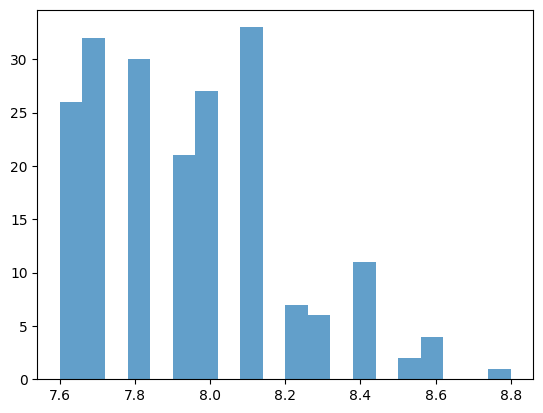

In [646]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # perfect prediction line
plt.xlabel("Actual IMDB Rating")
plt.ylabel("Predicted IMDB Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rating")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

# Rating distribution
plt.hist(y_test, bins=20, alpha=0.7, label="Actual")
plt

**DATASET 1: IMDb Ratings (Decision Tree Regressor)**

In [647]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R2:", tree_r2)

Decision Tree RMSE: 0.2562225595063792
Decision Tree R2: -0.002672775868652222


The reason why these models performed so badly is not because of the issue with how im getting the results. The models perform poorly because the features do not strongly capture the important factors that determine IMDb ratings.
For example, poor writing could mean lower ratings but also poor writing doesnt mean low gross income.

LETS TRY AGAIN: But this time I want to Predict the Gross

In [648]:
# ENCODING FOR THIS NEW MODELS

imdb_df["Released_Year"] = pd.to_numeric(imdb_df["Released_Year"], errors="coerce")

# Top-N One-Hot Encoding (Avoids unecessary creation of one off directors columns)
top_directors = imdb_df["Director"].value_counts().head(10).index
imdb_df["Top_Director"] = imdb_df["Director"].apply(lambda x: x if x in top_directors else "Other")
imdb_df = pd.get_dummies(imdb_df, columns=["Top_Director"])

# Taking the top directors from the top movies, we can split them from a single column (Director)
# and split them across multiple columns.
# Those being the top_director columns to tag if the top directors are associated with certain movies

imdb_df = imdb_df.drop("Poster_Link", axis=1)
imdb_df = imdb_df.drop("Series_Title", axis=1)
imdb_df = imdb_df.drop("Certificate", axis=1)

#gross from object -> Numeric and then logged
imdb_df["Gross"] = pd.to_numeric(imdb_df["Gross"], errors="coerce")
imdb_df["Gross"] = np.log1p(imdb_df["Gross"])

imdb_df = imdb_df.dropna(subset=["Released_Year"])

imdb_df.info()
imdb_df.head()

#Now its bool(32), float64(4), int64(2), object(5)

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Released_Year                   999 non-null    float64
 1   Runtime                         999 non-null    int64  
 2   IMDB_Rating                     999 non-null    float64
 3   Meta_score                      999 non-null    float64
 4   Director                        999 non-null    object 
 5   Star1                           999 non-null    object 
 6   Star2                           999 non-null    object 
 7   Star3                           999 non-null    object 
 8   Star4                           999 non-null    object 
 9   No_of_Votes                     999 non-null    int64  
 10  Gross                           999 non-null    float64
 11  Action                          999 non-null    bool   
 12  Adventure                       999 non-n

,Released_Year,Runtime,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,...,Top_Director_Alfred Hitchcock,Top_Director_Billy Wilder,Top_Director_Christopher Nolan,Top_Director_Clint Eastwood,Top_Director_Hayao Miyazaki,Top_Director_Martin Scorsese,Top_Director_Other,Top_Director_Stanley Kubrick,Top_Director_Steven Spielberg,Top_Director_Woody Allen
0,1994.0,142,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,...,False,False,False,False,False,False,True,False,False,False
1,1972.0,175,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,...,False,False,False,False,False,False,True,False,False,False
2,2008.0,152,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,...,False,False,True,False,False,False,False,False,False,False
3,1974.0,202,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,...,False,False,False,False,False,False,True,False,False,False
4,1957.0,96,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,...,False,False,False,False,False,False,True,False,False,False


LINEAR REGRESSION: Gross Prediction

In [649]:
#Linear Regression
X = imdb_df.drop(["Director", "Star1", "Star2", "Star3", "Star4", "Gross"], axis=1)

#Rather than predict the Gross of a movie, it instead predicts the Log(Gross) of a movie
y = np.log1p(imdb_df["Gross"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2
print("MSE:", np.sqrt(mse))
print("R2:", r2)

# Weak variability in the dataset so it results in a weaker R2, only features
# successful movies and not any low performing movies (Top 1000 IMDb)

MSE: 0.10728507818515938
R2: 0.34416306679458264


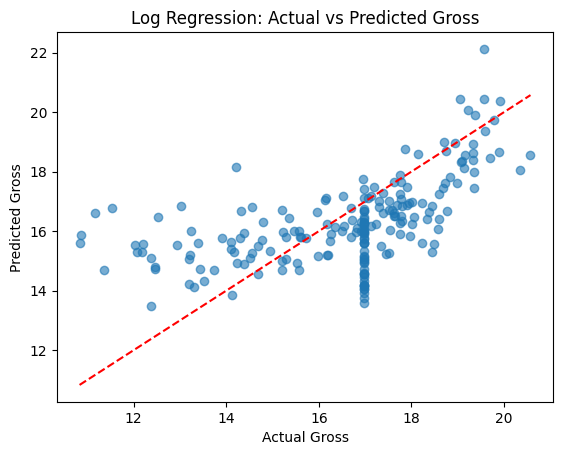

(array([ 3.,  2.,  4.,  5.,  6.,  5.,  7.,  9.,  6., 10.,  8.,  6., 54.,
        17., 18., 11., 11., 12.,  4.,  2.]),
 array([10.83350366, 11.32035594, 11.80720822, 12.2940605 , 12.78091279,
        13.26776507, 13.75461735, 14.24146963, 14.72832191, 15.2151742 ,
        15.70202648, 16.18887876, 16.67573104, 17.16258332, 17.6494356 ,
        18.13628789, 18.62314017, 19.10999245, 19.59684473, 20.08369701,
        20.5705493 ]),
 <BarContainer object of 20 artists>)

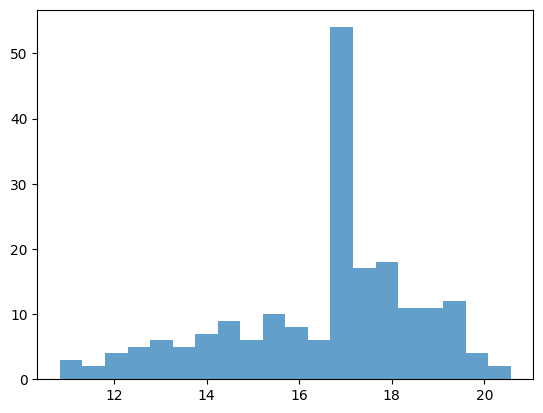

In [650]:
#Log Regression Scatter Plot
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

plt.scatter(y_test_real, y_pred_real, alpha=0.6)

plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--'
)
plt.xlabel("Actual Gross")
plt.ylabel("Predicted Gross")
plt.title("Log Regression: Actual vs Predicted Gross")
plt.show()

# Histogram
plt.hist(y_test_real, bins=20, alpha=0.7, label="Actual")

KNN R2: 0.1262230750436384
KNN RMSE: 0.013710950975586054


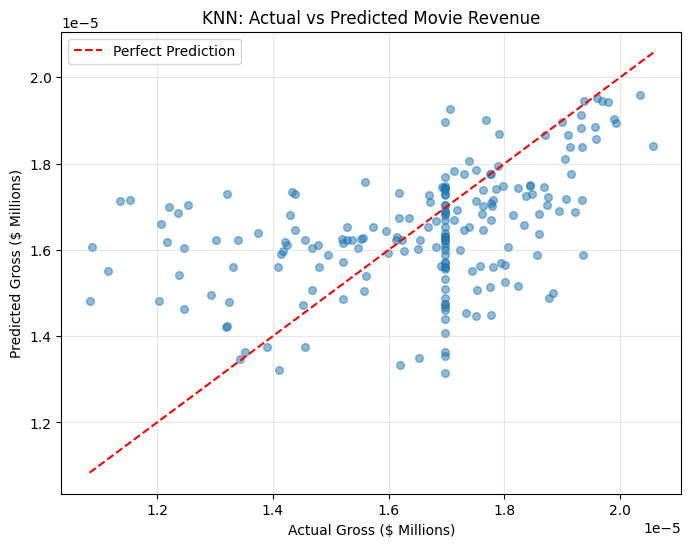

In [651]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluate
print("KNN R2:", r2_score(y_test, y_pred_knn))
print("KNN RMSE:", mean_squared_error(y_test, y_pred_knn))

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_knn)

y_test_m = y_test_real / 1e6
y_pred_m = y_pred_real / 1e6

plt.figure(figsize=(8,6))
plt.scatter(y_test_m, y_pred_m, alpha=0.5, s=30)

plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    'r--',
    label="Perfect Prediction"
)

plt.xlabel("Actual Gross ($ Millions)")
plt.ylabel("Predicted Gross ($ Millions)")
plt.title("KNN: Actual vs Predicted Movie Revenue")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

REATTEMPTING THE RATING MODELS WITH NEW ENCODING

In [652]:
X = model_df[["Released_Year", "Meta_score", "No_of_Votes", "Runtime"]]
y = model_df["IMDB_Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#Displays the average squared error and the Sq
print("MSE:", np.sqrt(mse))
print("R2:", r2)



MSE: 0.2058238963811664
R2: 0.35298241586063217


DATASET 2: Titanic


In [653]:
file_path = "test_data.csv"

titanic_df = kagglehub.dataset_load(
   KaggleDatasetAdapter.PANDAS,
  "azeembootwala/titanic",
  file_path,
  )

titanic_df.head()

titanic_df.info()

Using Colab cache for faster access to the 'titanic' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   100 non-null    int64  
 1   PassengerId  100 non-null    int64  
 2   Survived     100 non-null    int64  
 3   Sex          100 non-null    int64  
 4   Age          100 non-null    float64
 5   Fare         100 non-null    float64
 6   Pclass_1     100 non-null    int64  
 7   Pclass_2     100 non-null    int64  
 8   Pclass_3     100 non-null    int64  
 9   Family_size  100 non-null    float64
 10  Title_1      100 non-null    int64  
 11  Title_2      100 non-null    int64  
 12  Title_3      100 non-null    int64  
 13  Title_4      100 non-null    int64  
 14  Emb_1        100 non-null    int64  
 15  Emb_2        100 non-null    int64  
 16  Emb_3        100 non-null    int64  
dtypes: float64(3), int64(14)
memory

Luckily its a dataset with very minor issues, not much preprocessing was needed besides dropping a few columns like Unamed or PassengerId's

The dataset already seemed to have split the data for the class, titles, and Embarked into their own columns

There also wasnt any missing data in this dataset either, however, its important to note the dataset is rather small due to only containing 100 different rows leading to small test and training sets

**DATASET 2: Titanic Preprocessing**

In [654]:
#Drops any unnamed
titanic_df = titanic_df.drop(["Unnamed: 0", "PassengerId"], axis=1)
titanic_df.head()

,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,0,1,0.2000,0.050749,0,1,0,0.0,1,0,0,0,0,0,1
1,0,0,0.3500,0.135753,0,0,1,1.0,0,0,0,1,0,0,1
2,0,1,0.3500,0.059914,1,0,0,0.0,1,0,0,0,1,0,0
3,0,1,0.3125,0.015412,0,0,1,0.0,1,0,0,0,0,0,1
4,0,1,0.4875,0.025374,0,1,0,0.0,1,0,0,0,0,0,1


DATASET 2: Titanic Models

Titanic Logistic Regression (CLASSIFICATION for Survivors)

Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



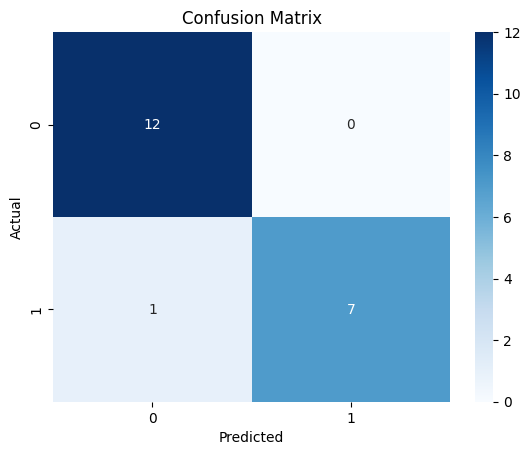

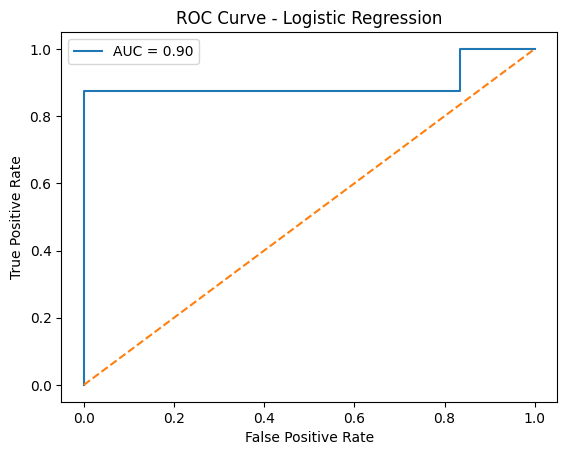

In [655]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#Confusion matrix and ROC curve

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plot

from sklearn.metrics import roc_curve, auc



X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

#20% of dataset as its testing set, 80% to train

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plot.xlabel("Predicted")
plot.ylabel("Actual")
plot.title("Logistic Regression - Confusion Matrix")
plot.show()

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

The model was trained on 80% of the data and correctly predicted 95% of the testing data (20%)

Titanic Decision Tree Classifier

In [656]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        12
           1       0.71      0.62      0.67         8

    accuracy                           0.75        20
   macro avg       0.74      0.73      0.73        20
weighted avg       0.75      0.75      0.75        20



Performed weaker than Logistic Regression, most likely due to an issue with overfitting. This is because of the rather small dataset used, only containing about 100 different rows


**DATASET 2: Hyperparameter Tuning** + Confusion Matrix

{'max_depth': 10, 'min_samples_split': 2}
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        12
           1       0.71      0.62      0.67         8

    accuracy                           0.75        20
   macro avg       0.74      0.73      0.73        20
weighted avg       0.75      0.75      0.75        20



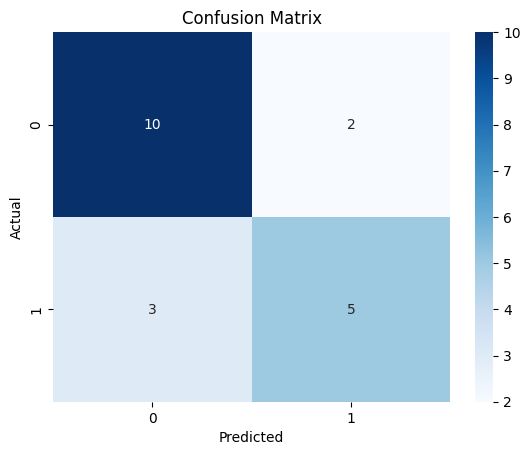

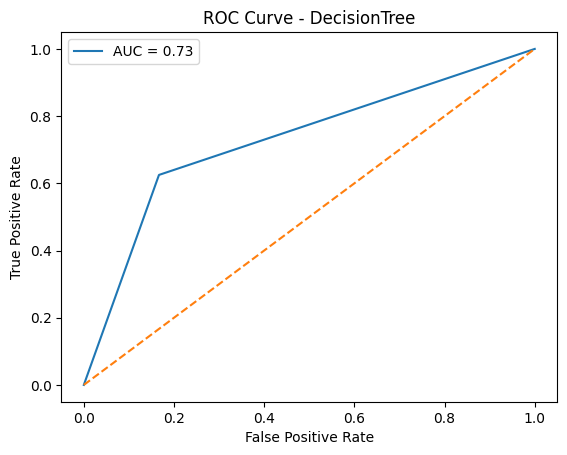

In [657]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)

best_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

best_tree.fit(X_train, y_train)

y_pred = best_tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plot.xlabel("Predicted")
plot.ylabel("Actual")
plot.title("Confusion Matrix")
plot.show()

y_prob = best_tree.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DecisionTree")
plt.legend()
plt.show()

Hyperparameter tuning did not improve the performance of the Decision Tree model. In terms of models, it appears that Logistic regression is the best performing due to the relationships between survivors, things like gender or class could oftentimes be linked to those who survived.

In decision Tree classifier, due to overfitting couldnt create patterns to help predict survivors

